# MiBiReMo Example: Field model tracer test with three well layouts

The tracer test of the example field_tracer_test is repeated with the four injection wells (INJ_1–4) at three
distances from the extraction well (EXT_1): 4 m, 6 m, and 10 m. The aquifer, the flow rates, and the tracer injection
(1.0 g m⁻³ during the first day) are the same as in field_tracer_test. The breakthrough curves and the tracer mass
recovery at the extraction well are compared for the three layouts.

MODFLOW 6 is required for running this notebook. Please install it using `get-modflow :python --subset mf6,libmf6`.

In [1]:
from dataclasses import replace
from pathlib import Path
import matplotlib.pyplot as plt
import mibiremo as mb

HOUR, DAY = 3600.0, 86400.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook

## Wells

For each injection-extraction distance, the injection wells are copies of the extraction well on a circle of that
radius around it (`array_radial`). The wells have the same names in the three layouts, so the flow rates are the
same: Q = 2.5 m³/d for each injection well and 4 Q for the extraction well.

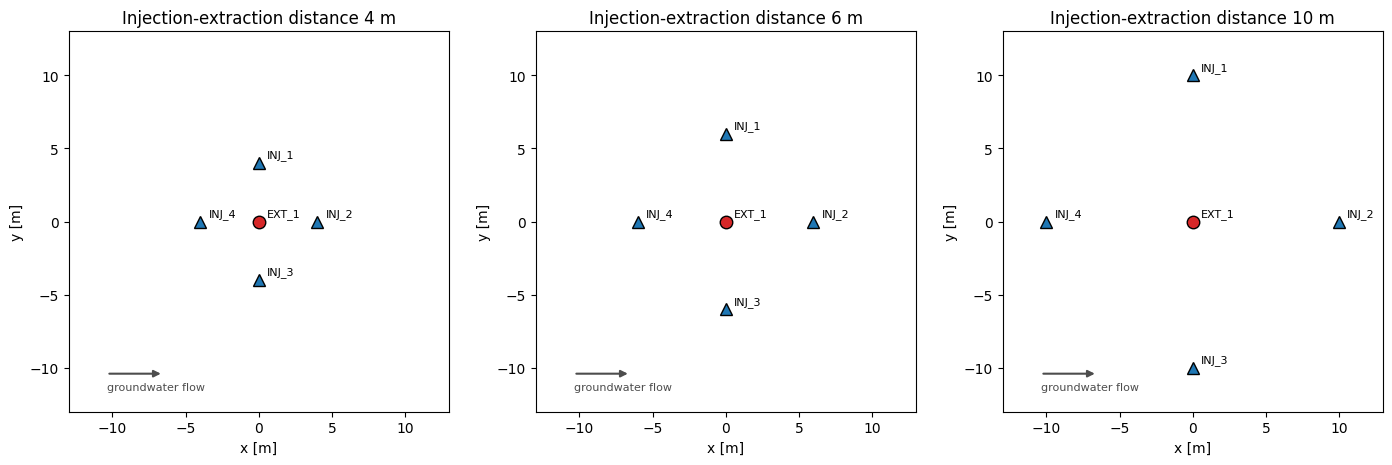

In [2]:
extraction = mb.Well(
    "EXT_1", x=0.0, y=0.0, well_top=96.3, well_bottom=90.5, diameter=0.1, screen_top=95.5, screen_bottom=90.5
)
distances = [4.0, 6.0, 10.0]  # injection-extraction distance [m]
layouts = {
    distance: [extraction, *mb.array_radial(replace(extraction, name="INJ"), n_wells=4, radius=distance)]
    for distance in distances
}

Q = 2.9e-5  # flow rate of each injection well [m3 s-1], 2.5 m3/d
flow_rates = {"EXT_1": -4 * Q} | {f"INJ_{i}": Q for i in range(1, 5)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
for ax, (distance, wells) in zip(axes, layouts.items()):
    mb.plotting.wells(ax, wells, flow_rates)
    ax.set(xlim=(-13, 13), ylim=(-13, 13), xlabel="x [m]", ylabel="y [m]")
    ax.set_title(f"Injection-extraction distance {distance:g} m")
    mb.plotting.flow_arrow(ax, 90.0)
plt.show()

## Model setup and simulation

The model is the same as in field_tracer_test and runs for 90 days instead of 30, so that the tracer injected 10 m
from the extraction well also reaches it. One model is built and run for each layout, in its own workspace. The grid
is refined around all the wells, so it grows with the injection-extraction distance.

In [3]:
models = {}
for distance, wells in layouts.items():
    model = mb.FieldModel(
        workspace=OUTPUT / "field_injection_extraction_distance" / f"distance_{distance:g}m",
        wells=wells,
        flow_rates=flow_rates,
        domain_size=(100.0, 100.0),
        top=95.5,
        bottom=90.5,
        hydraulic_conductivity=5e-6,
        porosity=0.25,
        reference_head=93.7,
        regional_hydraulic_gradient=0.01,
        regional_flow_azimuth=90.0,
        tracer_concentration=[(0.0, 1.0), (DAY, 0.0)],
        grid_spacing=4.0,
        grid_spacing_at_wells=0.5,
        simulation_time=90 * DAY,
        time_step=[(0.0, HOUR), (DAY, 4 * HOUR)],
    )
    model.run()
    models[distance] = model
    print(f"Injection-extraction distance {distance:g} m: grid {model.grid.nrow} rows x {model.grid.ncol} columns")

Injection-extraction distance 4 m: grid 63 rows x 63 columns


Injection-extraction distance 6 m: grid 71 rows x 71 columns


Injection-extraction distance 10 m: grid 85 rows x 85 columns


## Breakthrough curves and mass recovery

The concentration at EXT_1 is the flow-weighted mean over the screened cells. The recovery is the tracer mass
extracted by EXT_1 as a fraction of the injected tracer mass, from the MODFLOW 6 budget.

Injection-extraction distance 4 m: peak C = 0.112 g/m3 at 4.8 d, tracer mass recovered after 90 d: 93%


Injection-extraction distance 6 m: peak C = 0.058 g/m3 at 10.3 d, tracer mass recovered after 90 d: 88%


Injection-extraction distance 10 m: peak C = 0.025 g/m3 at 28.2 d, tracer mass recovered after 90 d: 75%


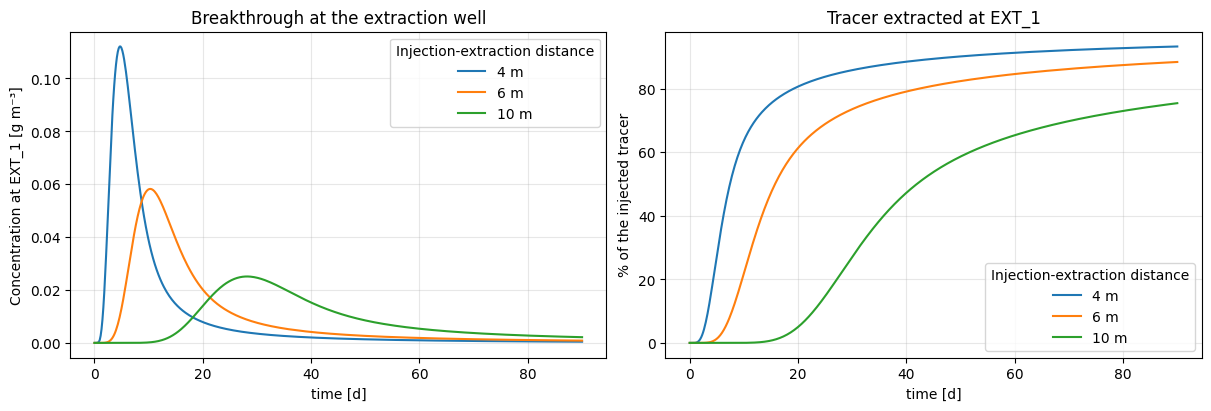

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for distance, model in models.items():
    curve = model.well_concentration("EXT_1")
    balance = model.mass_balance()
    peak = curve.loc[curve["concentration"].idxmax()]
    recovered = balance["extracted"] / balance["injected"].iloc[-1]
    print(
        f"Injection-extraction distance {distance:g} m: peak C = {peak['concentration']:.3f} g/m3 at "
        f"{peak['time'] / DAY:.1f} d, tracer mass recovered after 90 d: {recovered.iloc[-1]:.0%}"
    )
    axes[0].plot(curve["time"] / DAY, curve["concentration"], label=f"{distance:g} m")
    axes[1].plot(balance["time"] / DAY, 100 * recovered, label=f"{distance:g} m")
axes[0].set(xlabel="time [d]", ylabel="Concentration at EXT_1 [g m⁻³]", title="Breakthrough at the extraction well")
axes[1].set(xlabel="time [d]", ylabel="% of the injected tracer", title="Tracer extracted at EXT_1")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(title="Injection-extraction distance")
plt.show()

The farther the injection wells, the longer the tracer travels through the aquifer: the peak arrives later and is
lower, and the recovery is slower. The tracer not yet extracted is still in the aquifer (column `in_aquifer` of
`mass_balance`); none has left the domain across the boundary.